# NoteBook sur le cristal Ba2NF #

## 0. Importation des modules ##

In [17]:
from pymatgen.core import Lattice,Structure
from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import numpy as np
import pandas as pd
import itertools
import plotly.graph_objects as go
from pymatgen.analysis.diffraction.xrd import XRDCalculator

## 1. Importation de la structure ##

In [18]:
with MPRester("oq0PgNNYTST8xQ2xXfJpkLwNQFB5QgBT") as mpr:
    structure = mpr.get_structure_by_material_id("mp-1018096")

print(structure)

Full Formula (Ba2 N1 F1)
Reduced Formula: Ba2NF
abc   :   4.021645   4.021645   7.067405
angles:  73.469798  73.469807  59.999990
pbc   :       True       True       True
Sites (4)
  #  SP            a          b        c    magmom
---  ----  ---------  ---------  -------  --------
  0  Ba     0.757641   0.757641  0.72708        -0
  1  Ba     0.242359   0.242359  0.27292        -0
  2  N      0.5        0.5       0.5             0
  3  F     -0         -0         0              -0


## 2. Analyse de la maille élémentaire du Ba2NF ##

In [19]:
# Obtention des structures
spaceAnalyzer = SpacegroupAnalyzer(structure)
primitive = spaceAnalyzer.get_primitive_standard_structure()
conventional = spaceAnalyzer.get_conventional_standard_structure()

# Obtention du type de maille
lattice_type = spaceAnalyzer.get_lattice_type()
crystal = spaceAnalyzer.get_crystal_system()
group = spaceAnalyzer.get_point_group_symbol()

#Obtension du réseau direct
direct_vectors_primitive = primitive.lattice.matrix
longueurs_direct_primitive = primitive.lattice.abc
angles_direct_primitive = primitive.lattice.angles
direct_vectors_conventionnel = conventional.lattice.matrix
longueurs_direct_conventionnel = conventional.lattice.abc
angles_direct_conventionnel = conventional.lattice.angles

#Obtension du réseau réciproque
reciprocal_vectors_primitive = primitive.lattice.reciprocal_lattice.matrix
longueurs_reciprocal_primitive = primitive.lattice.reciprocal_lattice.abc
angles_reciprocal_primitive = primitive.lattice.reciprocal_lattice.angles
reciprocal_vectors_conventionnel = conventional.lattice.reciprocal_lattice.matrix
longueurs_reciprocal_conventionnel = conventional.lattice.reciprocal_lattice.abc
angles_reciprocal_conventionnel = conventional.lattice.reciprocal_lattice.angles

In [20]:
#Visualisation
def plot_structure_simple(structure):
    fig = go.Figure()
    coords = np.array(structure.cart_coords)
    species = [str(site.specie) for site in structure]
    color_map = {"Ba": "green", "N": "blue", "F": "red"}
    colors = [color_map.get(s, "black") for s in species]
    fig.add_trace(go.Scatter3d(
        x=coords[:, 0],
        y=coords[:, 1],
        z=coords[:, 2],
        mode="markers+text",
        text=species,
        textposition="top center",
        marker=dict(size=6, color=colors),
        showlegend=False   # ⭐ enlève "Trace 0"
    ))
    lattice = structure.lattice.matrix
    origin = np.array([0, 0, 0])
    a, b, c = lattice
    corners = [origin, a, b, c, a + b, a + c, b + c, a + b + c]
    edges = [(0, 1), (0, 2), (0, 3), (1, 4), (1, 5), (2, 4), (2, 6), (3, 5), (3, 6), (4, 7), (5, 7), (6, 7)]
    for i, j in edges:
        fig.add_trace(go.Scatter3d(
            x=[corners[i][0], corners[j][0]],
            y=[corners[i][1], corners[j][1]],
            z=[corners[i][2], corners[j][2]],
            mode="lines",
            line=dict(color="black"),
            showlegend=False   # ⭐ important aussi ici
        ))
    fig.update_layout(
        showlegend=False,  # ⭐ sécurité globale
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False)
        ),
        margin=dict(l=0, r=0, t=0, b=0)
    )
    return fig

In [21]:
#Affichage des résultats
resultats = [
    ("     ANALYSE DE LA MAILLE DU CRISTAL     ",""),
    ("",""),
    ("=====Informations cristallographiques=====",""),
    ("Type de maille",lattice_type),
    ("Système cristallin",crystal),
    ("Groupe ponctuel",group),
    ("",""),
    ("=====Maille primitive=====",""),
    ("-----Réseau direct-----",""),
    ("Vecteur a",direct_vectors_primitive[0]),
    ("Vecteur b",direct_vectors_primitive[1]),
    ("Vecteur c",direct_vectors_primitive[2]),
    ("Longueurs (a,b,c)",longueurs_direct_primitive),
    ("Angles (α,β,γ)", angles_direct_primitive),
    ("",""),
    ("-----Réseau réciproque-----",""),
    ("Vecteur a*",reciprocal_vectors_primitive[0]),
    ("Vecteur b*",reciprocal_vectors_primitive[1]),
    ("Vecteur c*",reciprocal_vectors_primitive[2]),
    ("Longueurs (a*,b*,c*)",longueurs_reciprocal_primitive),
    ("Angles (α*,β*,γ*)", angles_reciprocal_primitive),
    ("",""),
    ("=====Maille conventionnelle=====",""),
    ("-----Réseau direct-----",""),
    ("Vecteur a",direct_vectors_conventionnel[0]),
    ("Vecteur b",direct_vectors_conventionnel[1]),
    ("Vecteur c",direct_vectors_conventionnel[2]),
    ("Longueurs (a,b,c)",longueurs_direct_conventionnel),
    ("Angles (α,β,γ)", angles_direct_conventionnel),
    ("",""),
    ("-----Réseau réciproque-----",""),
    ("Vecteur a*",reciprocal_vectors_conventionnel[0]),
    ("Vecteur b*",reciprocal_vectors_conventionnel[1]),
    ("Vecteur c*",reciprocal_vectors_conventionnel[2]),
    ("Longueurs (a*,b*,c*)",longueurs_reciprocal_conventionnel),
    ("Angles (α*,β*,γ*)", angles_reciprocal_conventionnel)    
]

def print_result():
    data_frame = pd.DataFrame(resultats, columns=["Grandeur","Valeur"])
    for index,row in data_frame.iterrows():
        if row["Grandeur"] == "":
            print()
        else:
            print(f"{row['Grandeur']:<30}{row['Valeur']}")
    fig = plot_structure_simple(conventional)
    fig.show()

Via les différentes fonctions de SpacegroupeAnalyser, nous avons pu obtenir les informations cristallographiques de la maille ainsi que les vecteurs a, b et c ainsi que leurs longueurs et leurs angles, des réseaux direct et réciproques des mailles primitives et conventionnelles. Ces données se trouvent dans la sortie de la cellule suivante. Une représentation de la maille conventionnelle est également viualisable dans un plot suivant le tableau des données obtenues.

In [22]:
print_result()

     ANALYSE DE LA MAILLE DU CRISTAL     

=====Informations cristallographiques=====
Type de maille                rhombohedral
Système cristallin            trigonal
Groupe ponctuel               -3m

=====Maille primitive=====    
-----Réseau direct-----       
Vecteur a                     [0.         2.32189774 6.67510314]
Vecteur b                     [ 2.01082242 -1.16094887  6.67510314]
Vecteur c                     [-2.01082242 -1.16094887  6.67510314]
Longueurs (a,b,c)             (7.067404829619489, 7.067404829619489, 7.067404829619489)
Angles (α,β,γ)                (33.060392099605124, 33.060392099605124, 33.060392099605124)

-----Réseau réciproque-----   
Vecteur a*                    [3.46909648e-16 1.80403734e+00 3.13762208e-01]
Vecteur b*                    [ 1.56234216 -0.90201867  0.31376221]
Vecteur c*                    [-1.56234216 -0.90201867  0.31376221]
Longueurs (a*,b*,c*)          (1.8311191745036883, 1.831119174503688, 1.8311191745036877)
Angles (α*,β*,γ*)   

## 3. Les effets de trois symétries ##

In [23]:
#Calcul des symétries
sites = conventional.sites
for i, site in enumerate(sites):
    print(f"Atome {i} : {site.specie}")
    print(f"  Coordonnées fractionnaires : {site.frac_coords}")
    print(f"  Coordonnées cartésiennes   : {conventional.lattice.get_cartesian_coords(site.frac_coords)}\n")
    
Ba_sites = [s.frac_coords for s in sites if s.specie.symbol == "Ba"]
N_sites  = [s.frac_coords for s in sites if s.specie.symbol == "N"]
F_sites  = [s.frac_coords for s in sites if s.specie.symbol == "F"]

Ba_pos = Ba_sites[0]
N_pos  = N_sites[0]
F_pos  = F_sites[1]

print("Ba :", Ba_pos)
print("N  :", N_pos)
print("F  :", F_pos)

sga = SpacegroupAnalyzer(conventional)
symmops = sga.get_symmetry_operations()

# Symétrie 1
op1 = symmops[6]
Ba_new = op1.operate(Ba_pos) % 1

# Symétrie 2
op2 = symmops[1]
N_new = op2.operate(N_pos) % 1

# Symétrie 3
op3 = symmops[3]
F_new = op3.operate(F_pos) % 1

Atome 0 : Ba
  Coordonnées fractionnaires : [0.         0.         0.75764002]
  Coordonnées cartésiennes   : [ 0.          0.         15.17197576]

Atome 1 : Ba
  Coordonnées fractionnaires : [0.33333333 0.66666667 0.90902665]
  Coordonnées cartésiennes   : [ 2.01082242  1.16094887 18.20353994]

Atome 2 : Ba
  Coordonnées fractionnaires : [0.66666667 0.33333333 0.09097335]
  Coordonnées cartésiennes   : [ 2.01082242 -1.16094887  1.82176948]

Atome 3 : Ba
  Coordonnées fractionnaires : [1.         0.         0.24235998]
  Coordonnées cartésiennes   : [ 2.01082242 -3.4828466   4.85333366]

Atome 4 : Ba
  Coordonnées fractionnaires : [0.33333333 0.66666667 0.42430668]
  Coordonnées cartésiennes   : [2.01082242 1.16094887 8.49687262]

Atome 5 : Ba
  Coordonnées fractionnaires : [0.66666667 0.33333333 0.57569332]
  Coordonnées cartésiennes   : [ 2.01082242 -1.16094887 11.5284368 ]

Atome 6 : N
  Coordonnées fractionnaires : [0.66666667 0.33333333 0.83333333]
  Coordonnées cartésiennes   : 

In [24]:
#Visualisatin des symétries

def print_symetrie1():
    print("   OPERATION DE SYMETRIE 1")
    print("-----Matrice et vecteur-----")
    print("Matrice R :\n", op1.rotation_matrix)
    print("Vecteur t :", op1.translation_vector)
    print("-----Positions initiale et finale-----")
    print("Position initiale (Ba)    :", Ba_pos)
    print("Position transformée (Ba) :", Ba_new)

def print_symetrie2():
    print("   OPERATION DE SYMETRIE 2")
    print("-----Matrice et vecteur-----")
    print("Matrice R :\n", op2.rotation_matrix)
    print("Vecteur t :", op2.translation_vector)
    print("-----Positions initiale et finale-----")
    print("Position initiale (N)    :", N_pos)
    print("Position transformée (N) :", N_new)

def print_symetrie3():
    print("   OPERATION DE SYMETRIE 3")
    print("-----Matrice et vecteur-----")
    print("Matrice R :\n", op3.rotation_matrix)
    print("Vecteur t :", op3.translation_vector)
    print("-----Positions initiale et finale-----")
    print("Position initiale (F)    :", F_pos)
    print("Position transformée (F) :", F_new)

### a) Première symétrie ###

Pour la première symétrié, nous avons appliqué une inversion selon l'axe $x=y$ dans le plan $xy$ et une inversion selon l'axe $z$. C'est donc une rotation autout de l'axe cristallographique [110] d'ordre 2.

Sa matrice de rotation est $ R=
\begin{pmatrix}
0 & 1 & 0 \\
1 & 0 & 0 \\
0 & 0 & -1
\end{pmatrix}$
et son vecteur de translation est $\tau = (0,0,0)$.

Dans la sortie de la cellule de code suivante, il y a l'atome original de Ba et sa position finale. On remarque qu'elle est identique à celle d'un autre atome de Ba avant l'application de la symétrie. (cfr coordonnées des atomes de la maille dans la sortie de la cellele "Calcul des symétries").

In [25]:
print_symetrie1()

   OPERATION DE SYMETRIE 1
-----Matrice et vecteur-----
Matrice R :
 [[ 0.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
Vecteur t : [0. 0. 0.]
-----Positions initiale et finale-----
Position initiale (Ba)    : [0.         0.         0.75764002]
Position transformée (Ba) : [0.         0.         0.24235998]


### b) Deuxième symétrie ###

Pour la deuxième symétrié, nous avons appliqué une inversion centrale. Il s'agit donc d'une opération de symétrie d'ordre 2.

Sa matrice de rotation est $ R=
\begin{pmatrix}
-1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{pmatrix}$
et son vecteur de translation est $\tau = (0,0,0)$.

Dans la sortie de la cellule de code suivante, il y a l'atome original de N et sa position finale. On remarque qu'elle est identique à celle d'un autre atome de N avant l'application de la symétrie. (cfr coordonnées des atomes de la maille dans la sortie de la cellele "Calcul des symétries").

In [26]:
print_symetrie2()

   OPERATION DE SYMETRIE 2
-----Matrice et vecteur-----
Matrice R :
 [[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur t : [0. 0. 0.]
-----Positions initiale et finale-----
Position initiale (N)    : [0.66666667 0.33333333 0.83333333]
Position transformée (N) : [0.33333333 0.66666667 0.16666667]


### c) Troisième symétrie ###

Pour la troisième symétrié, nous avons appliqué une rotation de 120° dans le plan $xy$ (rotation d'ordre 3) et une inversion selon l'axe $z$. C'est une roto-inversion d'ordre 6.

Sa matrice de rotation est $ R=
\begin{pmatrix}
0 & 1 & 0 \\
-1 & 1 & 0 \\
0 & 0 & -1
\end{pmatrix}$
et son vecteur de translation est $\tau = (0,0,0)$.

Dans la sortie de la cellule de code suivante, il y a l'atome original de F et sa position finale. On remarque qu'elle est identique à celle d'un autre atome de F avant l'application de la symétrie. (cfr coordonnées des atomes de la maille dans la sortie de la cellele "Calcul des symétries").

In [27]:
print_symetrie3()

   OPERATION DE SYMETRIE 3
-----Matrice et vecteur-----
Matrice R :
 [[ 0.  1.  0.]
 [-1.  1.  0.]
 [ 0.  0. -1.]]
Vecteur t : [0. 0. 0.]
-----Positions initiale et finale-----
Position initiale (F)    : [0.66666667 0.33333333 0.33333333]
Position transformée (F) : [0.33333333 0.66666667 0.66666667]


## 4. Zone de Brillouin ##

In [28]:
def plot_brillouin_zone_simple(struc):

    bz_lattice = struc.lattice.reciprocal_lattice
    fig = go.Figure()

    origin = bz_lattice.get_cartesian_coords([0, 0, 0])
    axes = [
        ([1, 0, 0], "a*"),
        ([0, 1, 0], "b*"),
        ([0, 0, 1], "c*")
    ]

    for vec, label in axes:
        end = bz_lattice.get_cartesian_coords(vec)
        fig.add_trace(go.Scatter3d(
            x=[origin[0], end[0]],
            y=[origin[1], end[1]],
            z=[origin[2], end[2]],
            mode="lines+text",
            text=["", label],
            line=dict(color="green")
        ))

    ws = bz_lattice.get_wigner_seitz_cell()
    for iface in range(len(ws)):
        for line in itertools.combinations(ws[iface], 2):
            for jface in range(len(ws)):
                if (iface < jface
                    and any(np.all(line[0] == x) for x in ws[jface])
                    and any(np.all(line[1] == x) for x in ws[jface])):

                    fig.add_trace(go.Scatter3d(
                        x=[line[0][0], line[1][0]],
                        y=[line[0][1], line[1][1]],
                        z=[line[0][2], line[1][2]],
                        mode="lines",
                        line=dict(color="black")
                    ))
    high_sym_k = {
        "Γ": [0, 0, 0],
        "X": [0.5, 0, 0],
        "Y": [0, 0.5, 0],
        "Z": [0, 0, 0.5]
    }

    points = []
    labels = []
    for k, frac in high_sym_k.items():
        cart = bz_lattice.get_cartesian_coords(frac)
        points.append(cart)
        labels.append(k)
    fig.add_trace(go.Scatter3d(
        x=[p[0] for p in points],
        y=[p[1] for p in points],
        z=[p[2] for p in points],
        mode="markers+text",
        text=labels,
        marker=dict(size=5, color="red")
    ))
    fig.update_layout(
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False)
        )
    )
    return fig

La fonction utilisée permet de visualiser la zone de Brillouin du cristal à partir du réseau réciproque associé à la structure. La zone de Brillouin, est définie comme la cellule de Wigner-Seitz du réseau réciproque. Dans cette représentation, les vecteurs de base du réseau réciproque sont d’abord tracés afin de fournir une référence géométrique de l’espace k. La zone de Brillouin est ensuite reconstruite à partir de sa définition géométrique.

Cette visualisation permet d’identifier clairement la géométrie de la zone de Brillouin. Elle est visible dans le sortie de la cellule de code suivante.

In [29]:
fig = plot_brillouin_zone_simple(conventional)
fig.show()

# 4. Diffractogramme #

In [30]:
#Calcul du diffractogramme et des trois premiers pics

def diffractogramme():
    xrd = XRDCalculator(wavelength=1.54060)
    pattern = xrd.get_pattern(conventional)
    hkl = pattern.hkls
    d_hkl = pattern.d_hkls

    # Pic 1
    print("Pic de diffraction n°1\n")
    print("Angle de diffraction (2θ) =", round(pattern.x[0], 4), "[°]")
    print("Intensité relative =", round(pattern.y[0], 4))
    print("Indices hkl =", hkl[0][0]["hkl"])
    print("Multiplicité =", hkl[0][0]["multiplicity"])
    print("Distance interplanaire =", round(d_hkl[0], 4), "[Å]")

    print("\n" + "="*50 + "\n")

    # Pic 2
    print("Pic de diffraction n°2\n")
    print("Angle de diffraction (2θ) =", round(pattern.x[1], 4), "[°]")
    print("Intensité relative =", round(pattern.y[1], 4))
    print("Indices hkl =", hkl[1][0]["hkl"])
    print("Multiplicité =", hkl[1][0]["multiplicity"])
    print("Distance interplanaire =", round(d_hkl[1], 4), "[Å]")

    print("\n" + "="*50 + "\n")

    # Pic 3
    print("Pic de diffraction n°3\n")
    print("Angle de diffraction (2θ) =", round(pattern.x[2], 4), "[°]")
    print("Intensité relative =", round(pattern.y[2], 4))
    print("Indices hkl =", hkl[2][0]["hkl"])
    print("Multiplicité =", hkl[2][0]["multiplicity"])
    print("Distance interplanaire =", round(d_hkl[2], 4), "[Å]")

    #graphique
    xrd.get_plot(conventional, two_theta_range=(0,27))

Pour analyser les trois premier pics du diffractogramme pour un rayonnement X incident Cu Kα de longueur d’onde λ=1.54060 Å, nous avons utilisé les propriétés physiques de la diffraction dans un crystal. En effet, lorsqu'un rayonnement X incident est envoyé sur un cristal, le faisceau est diffracté à cause du réseau atmique et des interférences constructives et destructives apparaissent. L’interférence sera constructive lorque le vecteur d’onde $k$ appartient au plan de Bragg. Ces angles sont calculés grâce loi de Bragg : $2d_{hkl}\sin{(\theta)}=n\lambda$.

L'intensité des pics de diffraction dépend du facteur de forme de l'atome et de la multiplicité des plans de réflexion. La distance entre deux plans $(h,k,l)$ consécutifs du réseau direct est donnée par $d_{hkl}=\frac{2\pi}{\vert v \vert}$.

Tous ces calcules sont réalisées via le module XRDCalculator.

Les valeurs de ces données sont disponibles dans la sortie de la cellule de code suivant ainsi qu'un graphique permettant de visualiser ces pics.

Pic de diffraction n°1

Angle de diffraction (2θ) = 13.2533 [°]
Intensité relative = 3.2022
Indices hkl = (0, 0, 0, 3)
Multiplicité = 2
Distance interplanaire = 6.6751 [Å]


Pic de diffraction n°2

Angle de diffraction (2θ) = 25.9458 [°]
Intensité relative = 0.6478
Indices hkl = (1, 0, -1, 1)
Multiplicité = 12
Distance interplanaire = 3.4313 [Å]


Pic de diffraction n°3

Angle de diffraction (2θ) = 26.6881 [°]
Intensité relative = 27.5067
Indices hkl = (0, 0, 0, 6)
Multiplicité = 2
Distance interplanaire = 3.3376 [Å]


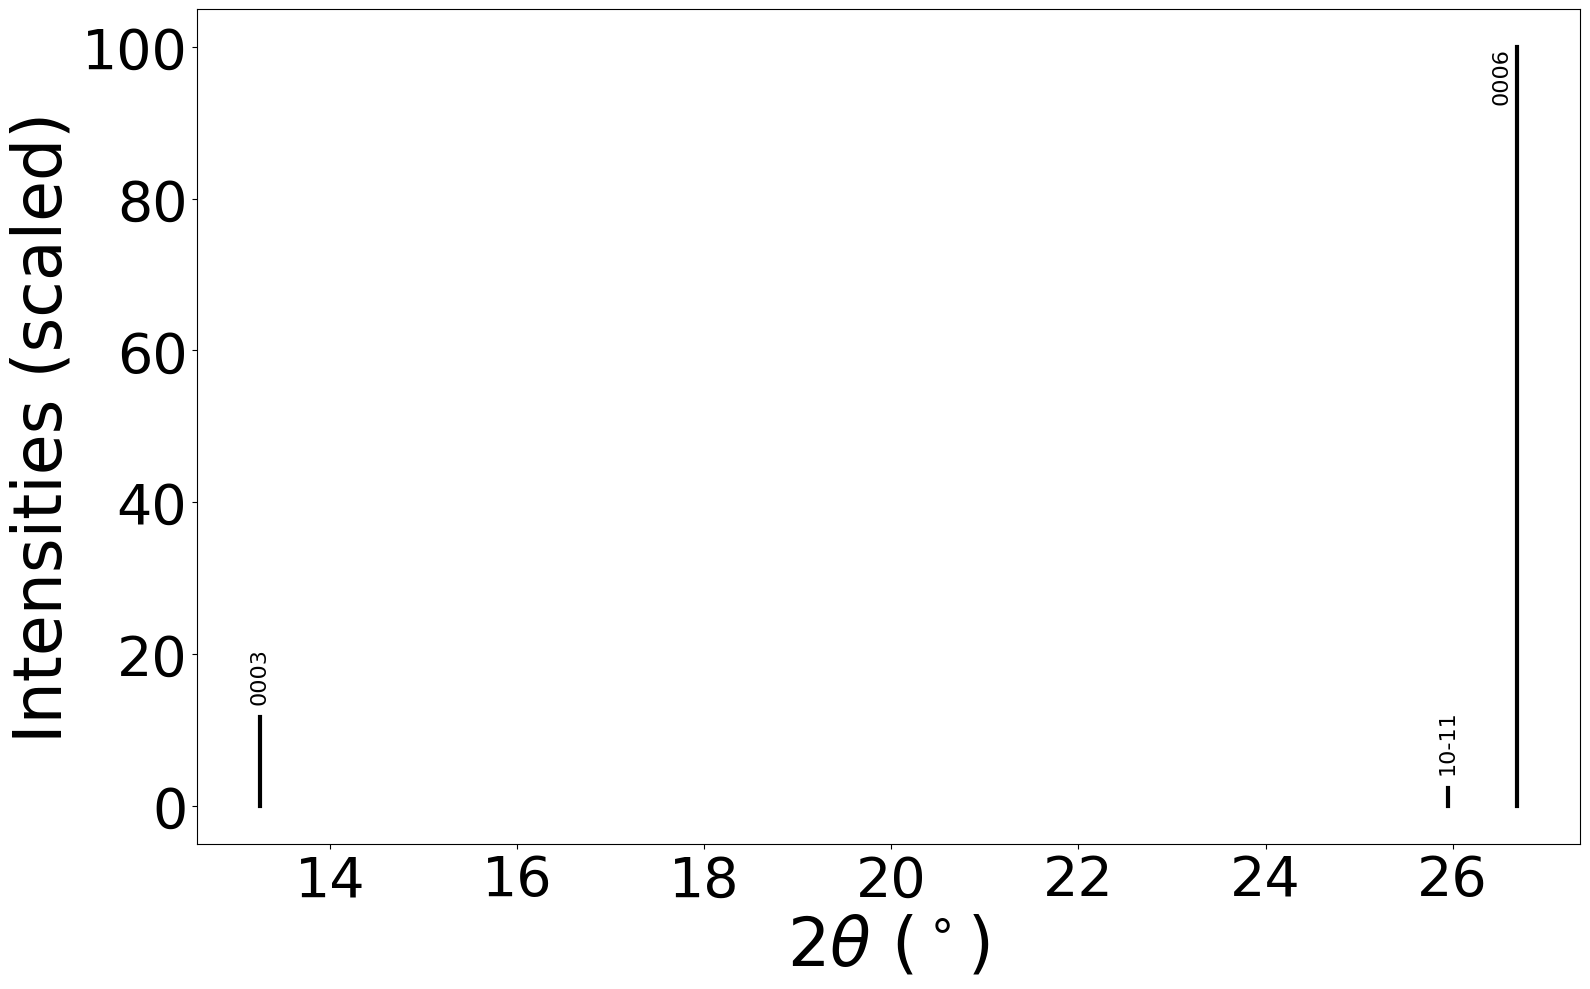

In [31]:
diffractogramme()